# 📘 Notebook 3: Classification and Reliable Predictions
**MATH 6388 — Statistical and Machine Learning**  
**Instructor: Farhad Pourkamali**  

- In NB2, we built a loss by choosing a conditional distribution for a continuous response. Here, the response is a class label.
- We follow the same sequence: choose a distribution, parameterize its probabilities, derive the negative log-likelihood, and train a model. Next, we focus on evaluating classifiers to measure their confidence in their predictions.
- By the end of this module, you should be able to derive binary and multiclass cross-entropy; distinguish logits, probabilities, and decisions; train and evaluate PyTorch classifiers; and diagnose confidence calibration.


### Before starting
Review NB2's likelihood approach, `nn.Module`, and `backward()`. Run cells in order. All examples run on CPU, use fixed seeds, and need no dataset downloads. Two moons is generated locally; digits is bundled with scikit-learn. Exact results can vary slightly across library versions.


In [1]:
import copy
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import scipy
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, ConfusionMatrixDisplay)
from scipy.optimize import minimize_scalar
from IPython.display import display

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print({"Python": platform.python_version(), "PyTorch": torch.__version__,
       "NumPy": np.__version__, "scikit-learn": sklearn.__version__,
       "SciPy": scipy.__version__})

{'Python': '3.13.7', 'PyTorch': '2.13.0', 'NumPy': '2.5.2', 'scikit-learn': '1.9.1', 'SciPy': '1.18.1'}


## From a Bernoulli model to a binary classifier
Let $ S=\{(\mathbf x_n,y_n)\}_{n=1}^N$, with $\mathbf x_n\in\mathbb R^D$ and $y_n\in\{0,1\}$. Write
$$y\mid\mathbf x\sim\operatorname{Bernoulli}(p_\theta(\mathbf x)),\qquad
p(y\mid\mathbf x;\theta)=p_\theta(\mathbf x)^y[1-p_\theta(\mathbf x)]^{1-y}.$$
A model must produce $p_\theta(\mathbf x)\in[0,1]$. We use a real-valued **logit** $a_\theta(\mathbf x)$ and the sigmoid:
$$p_\theta(\mathbf x)=\sigma(a_\theta(\mathbf x)),\qquad \sigma(a)=\frac{1}{1+e^{-a}}.$$
For logistic regression, $a_\theta(\mathbf x)=\mathbf w^T\mathbf x+b$. For a neural network, the logit is a nonlinear function of the input. Both use the same Bernoulli model and loss.

Why “logit”? Since $p/(1-p)=e^a$,
$$\log\frac{p}{1-p}=a.$$
Thus logistic regression assumes that **log-odds**, rather than probability itself, are affine in the input.

The sigmoid derivative is
$$\sigma'(a)=\sigma(a)[1-\sigma(a)].$$

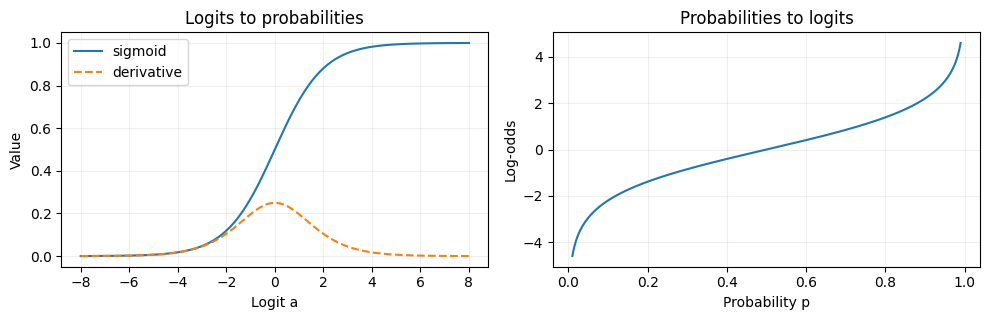

In [ ]:
a = torch.linspace(-8, 8, 300)
p = torch.sigmoid(a)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
axes[0].plot(a, p, label="sigmoid")
axes[0].plot(a, p * (1-p), "--", label="derivative")
axes[0].set(xlabel="Logit a", ylabel="Value", title="Logits to probabilities")
axes[0].legend()

q = np.linspace(.01, .99, 300)
axes[1].plot(q, np.log(q / (1-q)))
axes[1].set(xlabel="Probability p", ylabel="Log-odds", title="Probabilities to logits")
for ax in axes: ax.grid(alpha=.2)
plt.tight_layout(); plt.show()

✏️  Problem 3.1

Consider the sigmoid function

$$
p=\sigma(a)=\frac{1}{1+e^{-a}},
\qquad a\in\mathbb{R}.
$$

**(a)** Show that the log-odds satisfy

$$
\log\left(\frac{p}{1-p}\right)=a.
$$

**(b)** Show that the derivative of the sigmoid function can be written as

$$
\sigma'(a)=\sigma(a)\bigl[1-\sigma(a)\bigr].
$$

Show the intermediate steps in both derivations.

### Deriving binary cross-entropy
Assuming conditional independence of labels given the inputs and parameters,
$$L(\theta)=\prod_{n=1}^N p_n^{y_n}(1-p_n)^{1-y_n},\qquad p_n=p_\theta(\mathbf x_n).$$
Maximizing likelihood is equivalent to minimizing the average negative log-likelihood:
$$\begin{aligned}
 NLL(\theta)&=-\frac1N\log L(\theta)\\
&=-\frac1N\sum_{n=1}^N\left[y_n\log p_n+(1-y_n)\log(1-p_n)\right].
\end{aligned}$$
The per-observation **binary cross-entropy (BCE)** is $-\log p$ if $y=1$ and $-\log(1-p)$ if $y=0$. A confident error is penalized heavily: assigning probability $0.01$ to the true class costs about $4.605$, versus $0.105$ for probability $0.9$.

**PyTorch convention:** return raw logits and use `nn.BCEWithLogitsLoss()`. Apply `sigmoid` later when probabilities are needed. The loss already combines the probability transformation and BCE calculation stably.

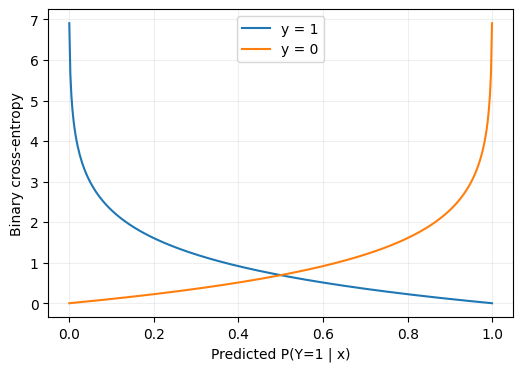

In [ ]:
p_grid = np.linspace(.001, .999, 400)
plt.figure(figsize=(6, 4))
plt.plot(p_grid, -np.log(p_grid), label="y = 1")
plt.plot(p_grid, -np.log1p(-p_grid), label="y = 0")
plt.xlabel("Predicted P(Y=1 | x)"); plt.ylabel("Binary cross-entropy")
plt.legend(); plt.grid(alpha=.2); plt.show()


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=.7,
    random_state=1
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Standardize using training-set statistics.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

# Match the model's output shape: (number of observations, 1).
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

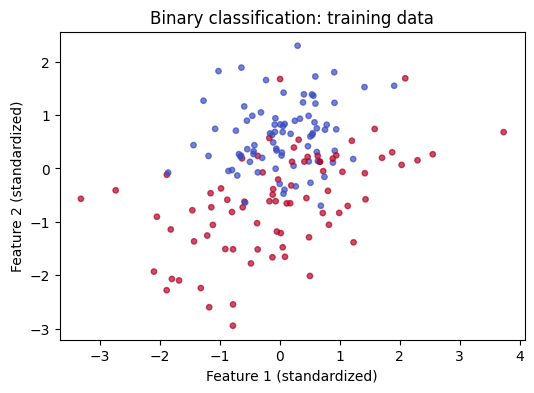

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train.flatten(),
    cmap="coolwarm",
    s=15,
    alpha=0.7
)
plt.xlabel("Feature 1 (standardized)")
plt.ylabel("Feature 2 (standardized)")
plt.title("Binary classification: training data")
plt.show()

In [ ]:
torch.manual_seed(42)

model = nn.Linear(
    in_features=2,
    out_features=1
)

loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1
)

In [ ]:
n_epochs = 1000

model.train()

for epoch in range(n_epochs):
    # Forward pass: raw logits.
    logits = model(X_train)

    # Binary cross-entropy directly from logits.
    loss = loss_fn(logits, y_train)

    # Compute gradients and update the parameters.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1:3d} | Loss: {loss.item():.4f}")

Epoch 100 | Loss: 0.4583
Epoch 200 | Loss: 0.4264
Epoch 300 | Loss: 0.4173
Epoch 400 | Loss: 0.4138
Epoch 500 | Loss: 0.4122
Epoch 600 | Loss: 0.4115
Epoch 700 | Loss: 0.4112
Epoch 800 | Loss: 0.4110
Epoch 900 | Loss: 0.4109
Epoch 1000 | Loss: 0.4109


In [ ]:
model.eval()

with torch.no_grad():
    test_logits = model(X_test)
    test_probabilities = torch.sigmoid(test_logits)
    test_predictions = (test_probabilities >= 0.5).float()

    accuracy = (test_predictions == y_test).float().mean()

print(f"Test accuracy: {accuracy.item():.2%}")

Test accuracy: 80.00%


In [ ]:
print(test_probabilities)

tensor([[0.1264],
        [0.7918],
        [0.3024],
        [0.0803],
        [0.0769],
        [0.5410],
        [0.1899],
        [0.6108],
        [0.1595],
        [0.1863],
        [0.9995],
        [0.9804],
        [0.1171],
        [0.7193],
        [0.6996],
        [0.3801],
        [0.2292],
        [0.1316],
        [0.0675],
        [0.6380],
        [0.0114],
        [0.7958],
        [0.7842],
        [0.9971],
        [0.9644],
        [0.9858],
        [0.9460],
        [0.0399],
        [0.4245],
        [0.2328],
        [0.9812],
        [0.0621],
        [0.0668],
        [0.2003],
        [0.7092],
        [0.0427],
        [0.9932],
        [0.3530],
        [0.8534],
        [0.3092]])


In [ ]:
print(test_predictions)

tensor([[0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.]])


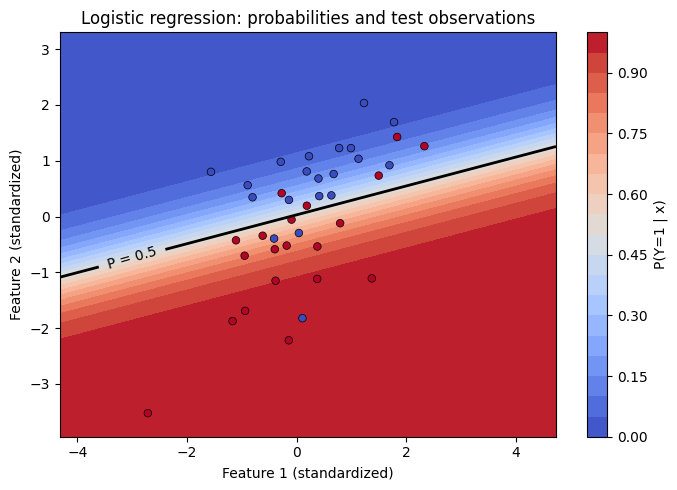

In [ ]:
import numpy as np

# Create a grid covering the training data.
x1 = np.linspace(
    X_train[:, 0].min().item() - 1.0,
    X_train[:, 0].max().item() + 1.0,
    200
)

x2 = np.linspace(
    X_train[:, 1].min().item() - 1.0,
    X_train[:, 1].max().item() + 1.0,
    200
)

xx, yy = np.meshgrid(x1, x2)

# Each row is one point in the grid.
X_grid = torch.tensor(
    np.column_stack([xx.ravel(), yy.ravel()]),
    dtype=torch.float32
)

# Compute the probability at every grid point.
model.eval()

with torch.no_grad():
    probabilities = torch.sigmoid(model(X_grid))

# Reshape probabilities to match the mesh.
Z = probabilities.numpy().reshape(xx.shape)

# Plot the probability surface.
fig, ax = plt.subplots(figsize=(7, 5))

contour = ax.contourf(
    xx, yy, Z,
    levels=np.linspace(0, 1, 21),
    cmap="coolwarm",
    vmin=0,
    vmax=1
)

fig.colorbar(contour, ax=ax, label="P(Y=1 | x)")

# Decision boundary.
boundary = ax.contour(
    xx, yy, Z,
    levels=[0.5],
    colors="black",
    linewidths=2
)
ax.clabel(boundary, fmt={0.5: "P = 0.5"})

# Overlay the test observations, colored by their true labels.
ax.scatter(
    X_test[:, 0].numpy(),
    X_test[:, 1].numpy(),
    c=y_test.flatten().numpy(),
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    edgecolors="black",
    linewidths=0.5,
    s=30
)

ax.set_xlabel("Feature 1 (standardized)")
ax.set_ylabel("Feature 2 (standardized)")
ax.set_title("Logistic regression: probabilities and test observations")

plt.tight_layout()
plt.show()

### Decisions are separate from probability estimation
With equal error costs, predict class 1 when $p\ge0.5$, equivalently $a\ge0$. A different threshold changes the decision rule without changing the model's probabilities.

Let $p=P(Y=1\mid\mathbf{x})$ be the model's predicted probability of class 1. Then $1-p=P(Y=0\mid\mathbf{x})$.

To choose a predicted class, we compare the **expected cost** of the two possible decisions. Suppose:

- A **false positive** means predicting 1 when the true class is 0, with cost $C_{FP}$.
- A **false negative** means predicting 0 when the true class is 1, with cost $C_{FN}$.
- Correct predictions have zero cost.

These costs describe the consequences of errors in the application. They are not automatically learned by the classifier. They may represent money, time, or relative penalties chosen with domain experts. For example, if missing an event is considered four times as costly as raising a false alarm, we can set $C_{FN}=4$ and $C_{FP}=1$. Only their ratio matters for the decision threshold.

#### What is the expected cost of predicting class 1?

If we predict 1, there are two possible outcomes:

- The true class is 1, with probability $p$: the prediction is correct and costs 0.
- The true class is 0, with probability $1-p$: the prediction is a false positive and costs $C_{FP}$.

Therefore,

$$
\text{Expected cost of predicting 1}
=0\cdot p+C_{FP}(1-p)
=C_{FP}(1-p).
$$

#### What is the expected cost of predicting class 0?

Similarly, predicting 0 is incorrect when the true class is 1, which occurs with probability $p$. Thus,

$$
\text{Expected cost of predicting 0}
=C_{FN}p+0\cdot(1-p)
=C_{FN}p.
$$

#### Compare the two decisions

We predict class 1 when its expected cost is no greater than the expected cost of predicting class 0:

$$
C_{FP}(1-p)\le C_{FN}p.
$$

Rearranging gives

$$
\begin{aligned}
C_{FP}-C_{FP}p &\le C_{FN}p,\\
C_{FP} &\le (C_{FP}+C_{FN})p,\\
p &\ge \frac{C_{FP}}{C_{FP}+C_{FN}}.
\end{aligned}
$$

Here, we assume the costs are nonnegative and their sum is positive. At equality, both decisions have the same expected cost; we choose class 1 as a tie-breaking convention.


✏️ Problem 3.2

Consider the binary classifier trained on the synthetic dataset above.
In this problem, keep the trained model fixed and use its test-set
probabilities to explore how error costs affect the predicted labels.

Recall that the cost-based decision rule predicts class 1 when

$$
p \geq \frac{C_{FP}}{C_{FP}+C_{FN}}.
$$

**(a)** Suppose a false negative is four times as costly as a false
positive: $C_{FN}=4C_{FP}$, where $C_{FP}>0$.

Determine the decision threshold and use it to generate predicted labels
from `test_probabilities`. Compare these predictions with `y_test` and
report:

- The number of false positives: predicted label 1, true label 0.
- The number of false negatives: predicted label 0, true label 1.

**(b)** Now suppose a false positive is four times as costly as a false
negative: $C_{FP}=4C_{FN}$, where $C_{FN}>0$.

Determine the new threshold, generate predicted labels, and report the
numbers of false positives and false negatives.

**(c)** Summarize your results for both cost settings and the original
threshold of 0.5 in a table with columns for the decision threshold,
number of false positives, and number of false negatives.


Use the same test probabilities in every case. Do not retrain the model
or choose a threshold by searching for the best test-set performance.
Include your code and results.

In [ ]:
# Flatten both arrays so comparisons match observations element by element.
probabilities = test_probabilities.detach().reshape(-1)
true_labels = y_test.reshape(-1).long()

print(f"{'Threshold':>10} | {'False positives':>15} | {'False negatives':>15}")
print("-" * 46)

for threshold in [0.2, 0.5, 0.8]:
    # Convert probabilities to labels using the current threshold.
    predicted_labels = (probabilities >= threshold).long()

    # False positive: predict 1 when the true label is 0.
    false_positives = (
        (predicted_labels == 1) & (true_labels == 0)
    ).sum().item()

    # False negative: predict 0 when the true label is 1.
    false_negatives = (
        (predicted_labels == 0) & (true_labels == 1)
    ).sum().item()

    print(
        f"{threshold:10.1f} | "
        f"{false_positives:15d} | "
        f"{false_negatives:15d}"
    )

### logistic regression versus a binary neural network
Two moons gives a nonlinear classification boundary that we can visualize. We reserve separate data for training, validation, calibration, and final testing. The calibration partition is retained here to introduce the same protocol used in Week 3.

| Partition | Allowed use |
|---|---|
| Train (about 55%) | Fit model weights and any learned preprocessing |
| Validation (about 15%) | Choose checkpoint, architecture, and other training choices |
| Calibration (about 15%) | Fit a post-training probability correction |
| Test (about 15%) | Final evaluation after all choices are fixed |


In [ ]:
def four_way_indices(y, seed=SEED):
    idx = np.arange(len(y))
    train, rest = train_test_split(idx, test_size=.45, stratify=y, random_state=seed)
    val, rest = train_test_split(rest, test_size=2/3, stratify=y[rest], random_state=seed+1)
    cal, test = train_test_split(rest, test_size=.5, stratify=y[rest], random_state=seed+2)
    groups = {"train": train, "val": val, "cal": cal, "test": test}
    assert len(np.unique(np.concatenate(list(groups.values())))) == len(y)
    return groups

X_moon, y_moon = make_moons(n_samples=2400, noise=.25, random_state=SEED)
moon_idx = four_way_indices(y_moon)


moon_scaler = StandardScaler().fit(X_moon[moon_idx["train"]])
moon = {name: (torch.tensor(moon_scaler.transform(X_moon[idx]), dtype=torch.float32),
               torch.tensor(y_moon[idx], dtype=torch.float32))
        for name, idx in moon_idx.items()}
print({name: len(idx) for name, idx in moon_idx.items()})


plt.figure(figsize=(6, 4))
idx = moon_idx["train"]
plt.scatter(X_moon[idx, 0], X_moon[idx, 1], c=y_moon[idx], cmap="coolwarm", s=10, alpha=.6)
plt.xlabel("Feature 1"); plt.ylabel("Feature 2"); plt.title("Training observations: two moons")
plt.show()

### 1.6 Models and tensor shapes
Our binary MLP has architecture $2\to32\to32\to1$. ReLU is applied after hidden linear layers; the final layer is linear so its output can be any real logit.

For a batch of size $B$, binary logits and floating-point targets both have shape `(B,)`. `squeeze(-1)` removes only the final singleton dimension, preserving the batch dimension even when $B=1$.

In [ ]:
class BinaryMLP(nn.Module):
    def __init__(self, input_dim=2, width=32):
        super().__init__()
        self.layers = nn.Sequential(nn.Linear(input_dim, width), nn.ReLU(),
                                    nn.Linear(width, width), nn.ReLU(),
                                    nn.Linear(width, 1))
    def forward(self, x):
        return self.layers(x).squeeze(-1) # remove the last dimension when its size is 1

class BinaryLogistic(nn.Module):
    def __init__(self, input_dim=2):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
    def forward(self, x):
        return self.linear(x).squeeze(-1) # remove the last dimension when its size is 1

print(BinaryMLP())

### 1.7 A reusable training loop
Each mini-batch performs `zero_grad → forward → loss → backward → step`. Validation uses `eval()` and `no_grad()` and never updates weights. We save a **deep copy** of the parameters whenever validation NLL improves and restore that checkpoint after training. A simple assignment of `state_dict()` would not preserve an independent snapshot.

The same helper works for binary and multiclass losses. The training loss is accumulated with batch-size weights so a smaller final batch is counted correctly. It averages losses observed during updates; validation loss is measured at the end of an epoch, so the two curves are not evaluated at identical parameter values.

In [ ]:
def fit_classifier(model, data, loss_fn, epochs=100, lr=.003,
                   batch_size=64, seed=SEED):

    Xtr, ytr = data["train"]
    Xv, yv = data["val"]

    # Shuffle training examples into mini-batches using a reproducible seed.
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(Xtr, ytr),
        batch_size=batch_size,
        shuffle=True,
        generator=generator
    )

    # Adam updates the model's trainable weights and biases.
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train": [], "val": []}
    best_loss, best_state, best_epoch = float("inf"), None, None

    for epoch in range(epochs):
        model.train()  # Enable training mode.
        total = 0.0

        for xb, yb in loader:
            optimizer.zero_grad(set_to_none=True)  # Clear previous gradients.
            loss = loss_fn(model(xb), yb)          # Forward pass and loss.
            loss.backward()                       # Compute gradients.
            optimizer.step()                      # Update model parameters.

            # Weight each batch's mean loss by its number of examples.
            total += loss.item() * len(xb)

        # Evaluate on validation data without computing gradients or updating weights.
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xv), yv).item()

        # Record the average training loss and validation loss for this epoch.
        history["train"].append(total / len(Xtr))
        history["val"].append(val_loss)

        # Save an independent copy of the parameters whenever validation improves.
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

    # Restore the best validation epoch, which may differ from the final epoch.
    model.load_state_dict(best_state)
    model.eval()

    print(f"Restored epoch {best_epoch}; validation NLL = {best_loss:.4f}")
    return history

def plot_history(histories):
    fig, axes = plt.subplots(1, len(histories), figsize=(4*len(histories), 3.3), squeeze=False)
    for ax, (name, history) in zip(axes[0], histories.items()):
        for partition, values in history.items():
            ax.plot(np.arange(1, len(values)+1), values, label=partition)
        ax.set(title=name, xlabel="Epoch", ylabel="NLL")
        ax.legend(); ax.grid(alpha=.2)
    plt.tight_layout(); plt.show()

torch.manual_seed(SEED)
moon_logistic = BinaryLogistic()
h_logistic = fit_classifier(moon_logistic, moon, nn.BCEWithLogitsLoss(), epochs=100)


torch.manual_seed(SEED)
moon_mlp = BinaryMLP()
h_moon = fit_classifier(moon_mlp, moon, nn.BCEWithLogitsLoss(), epochs=100)


plot_history({"Logistic regression": h_logistic, "Binary MLP": h_moon})

### Evaluate decisions and ranking
For the positive class, $\mathrm{precision}=TP/(TP+FP)$ and $\mathrm{recall}=TP/(TP+FN)$. F1 is their harmonic mean.

<img src="https://github.com/farhad-pourkamali/MATH6388/blob/main/images/confusion_matrix.png?raw=true\" width=400>


The models and threshold 0.5 are now fixed. Test results below are descriptive final results, not inputs to another model-selection round.

In [ ]:
rows = []
with torch.no_grad():
    for name, model in {"Logistic regression": moon_logistic, "Binary MLP": moon_mlp}.items():
        Xte, yte = moon["test"]
        logits = model(Xte)
        prob = logits.sigmoid().numpy()
        pred = (prob >= .5).astype(int)
        rows.append({"Model": name, "Accuracy": accuracy_score(yte, pred),
                     "Precision": precision_score(yte, pred, zero_division=0),
                     "Recall": recall_score(yte, pred, zero_division=0),
                     "F1": f1_score(yte, pred, zero_division=0),
                     "NLL": F.binary_cross_entropy_with_logits(logits, yte).item()})
display(pd.DataFrame(rows).set_index("Model").round(4))

xx, yy = np.meshgrid(np.linspace(-1.8, 2.8, 220), np.linspace(-1.4, 1.9, 180))
grid = torch.tensor(moon_scaler.transform(np.c_[xx.ravel(), yy.ravel()]), dtype=torch.float32)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, model) in zip(axes, {"Logistic regression": moon_logistic, "Binary MLP": moon_mlp}.items()):
    with torch.no_grad(): surface = model(grid).sigmoid().numpy().reshape(xx.shape)
    contour = ax.contourf(xx, yy, surface, levels=np.linspace(0, 1, 21), cmap="coolwarm", alpha=.8)
    ax.contour(xx, yy, surface, levels=[.5], colors="black", linewidths=1)
    idx = moon_idx["test"]
    ax.scatter(X_moon[idx, 0], X_moon[idx, 1], c=y_moon[idx], cmap="coolwarm", s=12, edgecolors="k", linewidths=.2)
    ax.set(title=name, xlabel="Feature 1", ylabel="Feature 2")
fig.colorbar(contour, ax=axes, label="P(Y=1 | x)", shrink=.8)
plt.show()

## From binary to multiclass classification

### From a Bernoulli distribution to a categorical distribution

In binary classification, the label takes one of two values: $y=0$ or $y=1$. We model this label using a **Bernoulli distribution**. Given an input $\mathbf{x}$, the model estimates a probability $p$ for class 1, and the probability of class 0 is $1-p$.

In multiclass classification, each observation belongs to **exactly one of $K$ classes**. For example, an image might represent a cat, a dog, or a bird. We use labels $0,1,\ldots,K-1$ to match the indexing convention in PyTorch.

Instead of estimating a single probability, the model now produces a vector containing one probability for each class:

$$
\mathbf{p}(\mathbf{x})
=
\begin{bmatrix}
p_0(\mathbf{x}) & p_1(\mathbf{x}) & \cdots & p_{K-1}(\mathbf{x})
\end{bmatrix}.
$$

These probabilities must be nonnegative and sum to one:

$$
p_k(\mathbf{x})\geq 0,
\qquad
\sum_{k=0}^{K-1}p_k(\mathbf{x})=1.
$$

We model the label using a **categorical distribution**, which generalizes the Bernoulli distribution to multiple classes:

$$
y\mid\mathbf{x}
\sim
\operatorname{Categorical}\bigl(\mathbf{p}(\mathbf{x})\bigr).
$$

This means that the model assigns probability $p_k(\mathbf{x})$ to the event that the true label is $k$:

$$
P(y=k\mid\mathbf{x};\theta)=p_k(\mathbf{x}).
$$

These are the model's estimated probabilities.

For example, suppose the class order is cat, dog, bird, and the model outputs

$$
\mathbf{p}(\mathbf{x})=[0.1,\;0.7,\;0.2].
$$

The model assigns a 10% probability to cat, 70% to dog, and 20% to bird. These probabilities describe its uncertainty about the label. If our goal is to minimize classification errors with equal costs, we predict the class with the largest estimated probability—in this case, dog.

### How does a neural network produce these probabilities?

In our binary models, the final linear layer produces one raw score, called a **logit**. Applying the sigmoid function converts that score into a probability.

For multiclass classification, we use a final linear layer with **$K$ outputs**, producing one logit per class:

$$
\mathbf{a}=f_\theta(\mathbf{x})\in\mathbb{R}^K.
$$

The logits can be any real numbers. They do not need to be positive or sum to one, so they cannot be interpreted directly as probabilities.

The **softmax function** converts the logits into a valid probability vector:

$$
p_k(\mathbf{x})
=
\frac{\exp(a_k)}
{\sum_{j=0}^{K-1}\exp(a_j)}.
$$

Exponentiation makes each numerator positive, and dividing by their sum ensures that the probabilities add up to one. A larger logit produces a larger probability, but that probability depends on all the logits.

The architectural change is therefore straightforward: we keep the hidden layers and replace the final layer that produces one score with a layer that produces $K$ scores. A model with no hidden layers gives multinomial logistic regression; a model with nonlinear hidden layers gives a multiclass MLP.


### What loss function should we use?

Training should encourage the model to assign a high probability to the **observed class**.

Suppose an example has label $y$. Under the categorical distribution, the probability assigned to that observed label is simply $p_y(\mathbf{x})$. For example, if the true label is dog, we select the dog probability from the output vector.

We define the loss as the **negative logarithm of this probability**:

$$
\ell(\theta;\mathbf{x},y)
=
-\log p_y(\mathbf{x}).
$$

This is the **categorical negative log-likelihood**, also called **multiclass cross-entropy loss** for a single observed class label.

To see how it behaves, consider three possible probabilities assigned to the correct class. Here, $\log$ denotes the natural logarithm.

| Probability assigned to the correct class | Loss: negative log-probability |
|---|---:|
| 0.9 | 0.105 |
| 0.5 | 0.693 |
| 0.1 | 2.303 |

Assigning a probability close to one to the correct class gives a loss close to zero. Assigning a probability close to zero gives a large loss. Because the class probabilities sum to one, increasing the probability of the correct class also reduces the total probability assigned to the other classes.

This extends the binary cross-entropy loss we used previously:

$$
\ell_{\mathrm{binary}}
=
-\left[y\log p+(1-y)\log(1-p)\right].
$$

For a binary label, this expression selects the negative log-probability of the observed class: $-\log p$ when $y=1$, and $-\log(1-p)$ when $y=0$. **Multiclass cross-entropy follows exactly the same principle**, but selects from $K$ class probabilities.

### Using the loss in PyTorch

Substituting the softmax expression into the loss gives

$$
\ell
=
-\log\left(
\frac{\exp(a_y)}
{\sum_{k=0}^{K-1}\exp(a_k)}
\right)
=
-a_y+\log\left(\sum_{k=0}^{K-1}\exp(a_k)\right).
$$

This form allows the loss to be computed directly from logits. PyTorch's `nn.CrossEntropyLoss()` performs this calculation in a numerically stable way, so **we pass raw logits to the loss without applying softmax first**.

For class-index targets:

- The model outputs logits with shape `[batch_size, K]`.
- The labels have shape `[batch_size]` and use the data type `torch.long`.
- Each label is an integer from `0` to `K - 1`.

Unlike the binary model, we retain the final class dimension: each example now has $K$ scores.

During prediction, we can apply softmax to inspect the class probabilities and use `argmax` to select the most probable class. Softmax preserves the ordering of the logits, so applying `argmax` directly to the logits gives the same class prediction.

### Worked example: handwritten digit classification
The "digits" dataset contains 1,797 grayscale $8\times8$ images labeled 0–9. We flatten each image into 64 features and divide pixel values by the known scale 16. This fixed rescaling does not estimate statistics from held-out examples.

We compare a linear multiclass head with an MLP $64\to64\to32\to10$. For the MLP, the trainable parameter count is
$$(64\cdot64+64)+(64\cdot32+32)+(32\cdot10+10)=6570.$$
An MLP ignores the explicit spatial arrangement after flattening; convolutional networks offer a useful extension but are not required for this module.

In [ ]:
digits = load_digits()
X_digits = (digits.data / 16.0).astype(np.float32)
y_digits = digits.target.astype(np.int64)

digit_idx = four_way_indices(y_digits)
digit_data = {name: (torch.tensor(X_digits[idx]), torch.tensor(y_digits[idx], dtype=torch.long))
              for name, idx in digit_idx.items()}
print({name: len(idx) for name, idx in digit_idx.items()})

fig, axes = plt.subplots(2, 6, figsize=(5, 3))
for ax, idx in zip(axes.flat, digit_idx["train"][:12]):
    ax.imshow(digits.images[idx], cmap="gray_r", vmin=0, vmax=16)
    ax.set_title(f"Label {y_digits[idx]}"); ax.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
class MulticlassMLP(nn.Module):
    def __init__(self, input_dim=64, num_classes=10):
        super().__init__()
        self.layers = nn.Sequential(nn.Linear(input_dim, 64), nn.ReLU(),
                                    nn.Linear(64, 32), nn.ReLU(),
                                    nn.Linear(32, num_classes))
    def forward(self, x):
        return self.layers(x)  # No softmax here.

torch.manual_seed(SEED)
digit_linear = nn.Linear(64, 10)
h_digit_linear = fit_classifier(digit_linear, digit_data, nn.CrossEntropyLoss(), epochs=100)

torch.manual_seed(SEED)
digit_mlp = MulticlassMLP()
print("MLP parameters:", sum(p.numel() for p in digit_mlp.parameters()))

h_digit_mlp = fit_classifier(digit_mlp, digit_data, nn.CrossEntropyLoss(), epochs=100)

plot_history({"Linear multiclass model": h_digit_linear, "Digit MLP": h_digit_mlp})

## Calibration: Can we trust the predicted probabilities?

### A predicted class does not tell the whole story

Consider a classification problem with three classes: cat, dog, and bird.
Suppose two models produce the following probabilities for the same image:

| Model | Cat | Dog | Bird | Predicted class |
|---|---:|---:|---:|---|
| A | 0.05 | 0.90 | 0.05 | Dog |
| B | 0.30 | 0.40 | 0.30 | Dog |

Both models predict **dog**, because dog has the largest probability.
However, their levels of confidence are very different: Model A assigns
90% probability to dog, while Model B assigns only 40%.

Classification accuracy treats these predictions identically: both are
correct if the image is a dog, and both are incorrect otherwise.
Accuracy does not tell us whether the reported probabilities are trustworthy.

This motivates the concept of **calibration**.

Informally, among predictions made with approximately 80% confidence,
we would like approximately 80% to be correct. Among predictions made
with approximately 60% confidence, we would like approximately 60% to
be correct.

Calibration is assessed across a collection of predictions. A single
incorrect prediction with 90% confidence does not, by itself, establish
that a model is miscalibrated.

### 2. Predicted class, confidence, and correctness

For observation $i$, let $p_{ik}$ denote the probability assigned to class $k$.
We define the predicted class and its confidence as

$$
\hat{y}_i
=
\operatorname*{arg\,max}_{k} p_{ik},
\qquad
q_i
=
\max_k p_{ik}.
$$

The confidence $q_i$ is the probability assigned to the class the model
actually predicts.

Once the true label $y_i$ is available, we can also record whether the
prediction was correct:

$$
r_i
=
\mathbf{1}\{\hat{y}_i=y_i\}.
$$

Here, $r_i=1$ for a correct prediction and $r_i=0$ for an incorrect prediction.

The ideal **top-label calibration** relationship is

$$
P(\hat{Y}=Y\mid Q=q)=q.
$$

In words: among predictions with confidence $q$, the fraction that are
correct should be $q$.

This evaluates the confidence of the selected class. It does not fully
evaluate the probabilities assigned to every other class.

### 3. Constructing a reliability diagram

In practice, we rarely have many predictions with exactly the same
confidence. Instead, we divide the confidence range into bins and group
predictions with similar confidence.

Let $B_m$ be the set of observations whose confidence falls in bin $m$.
For each nonempty bin, compute two quantities:

**Average confidence:**

$$
\operatorname{conf}(B_m)
=
\frac{1}{|B_m|}
\sum_{i\in B_m} q_i.
$$

**Empirical accuracy:**

$$
\operatorname{acc}(B_m)
=
\frac{1}{|B_m|}
\sum_{i\in B_m}
\mathbf{1}\{\hat{y}_i=y_i\}.
$$

A reliability diagram plots average confidence on the horizontal axis
and empirical accuracy on the vertical axis.

- Points near the diagonal indicate agreement between confidence and accuracy.
- Points below the diagonal indicate **overconfidence**.
- Points above the diagonal indicate **underconfidence**.

For example, suppose a bin contains 20 predictions with an average
confidence of 0.85. If only 14 predictions are correct, its accuracy is
14/20 = 0.70. We plot the point (0.85, 0.70), which lies below the
diagonal: confidence exceeds observed accuracy.

Bins containing few observations can be noisy. We should interpret
the diagram together with the number of observations in each bin.

### 4. Summarizing the diagram with ECE

The **expected calibration error (ECE)** summarizes the gaps between
confidence and accuracy:

$$
\operatorname{ECE}
=
\sum_{m:\,|B_m|>0}
\frac{|B_m|}{N}
\left|
\operatorname{acc}(B_m)
-
\operatorname{conf}(B_m)
\right|.
$$

Each bin's gap is weighted by the fraction of observations it contains.
A lower ECE indicates closer agreement under the chosen binning.

ECE is an estimate based on finite data and depends on the bin boundaries.
It should be interpreted alongside the reliability diagram rather than
treated as a complete measure of probability quality.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_reliability(probs, labels, n_bins=10, ax=None,
                     title="Reliability diagram"):
    """
    probs:  NumPy array with shape [N, K], one probability per class.
    labels: NumPy array with shape [N], containing integer class labels.
    """
    probs = np.asarray(probs)
    labels = np.asarray(labels).reshape(-1)

    # Select the most probable class and its associated confidence.
    predictions = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (predictions == labels)

    # Divide [0, 1] into equally spaced confidence bins.
    edges = np.linspace(0.0, 1.0, n_bins + 1)

    # Using only internal edges keeps confidence=0 and confidence=1
    # inside valid bins. A value on an internal edge enters the upper bin.
    bin_ids = np.digitize(confidence, edges[1:-1])

    mean_confidence = []
    accuracy = []
    counts = []
    ece = 0.0

    for m in range(n_bins):
        in_bin = (bin_ids == m)
        count = in_bin.sum()

        # Empty bins have no accuracy or mean confidence to estimate.
        if count == 0:
            continue

        bin_confidence = confidence[in_bin].mean()
        bin_accuracy = correct[in_bin].mean()

        mean_confidence.append(bin_confidence)
        accuracy.append(bin_accuracy)
        counts.append(count)

        # Weight the bin's calibration gap by its fraction of the data.
        ece += (count / len(labels)) * abs(bin_accuracy - bin_confidence)

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(mean_confidence, accuracy, "o-", label="Model")

    # Annotate each point with the number of observations in its bin.
    for x, y, count in zip(mean_confidence, accuracy, counts):
        ax.annotate(f"n={count}", (x, y),
                    xytext=(5, 5), textcoords="offset points", fontsize=8)

    ax.set(
        xlabel="Average confidence",
        ylabel="Empirical accuracy",
        title=f"{title}\nECE = {ece:.3f}",
        xlim=(0, 1),
        ylim=(0, 1),
    )
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
    ax.legend()

    return ece

In [ ]:
print(digit_data['test'][0].shape, '\n', digit_data['test'][1].shape)

In [ ]:
print(digit_data['test'][1][:12])

In [ ]:
with torch.no_grad():
    logits = digit_linear(digit_data['test'][0])
    probs = logits.softmax(dim=1).numpy()
    labels = digit_data['test'][1]


plot_reliability(probs, labels, n_bins=8)
plt.show()

### Temperature scaling

How can we adjust a trained model's confidence?

One simple approach is **temperature scaling**. We keep the trained
network fixed and divide its logits by a positive scalar $T$ before
converting them to probabilities.

For multiclass classification, the adjusted probabilities are

$$
p_k^{(T)}(\mathbf{x})
=
\frac{\exp(a_k(\mathbf{x})/T)}
{\sum_{j=0}^{K-1}\exp(a_j(\mathbf{x})/T)}.
$$

The temperature controls how concentrated the probabilities are:

- $T=1$: the original probabilities are unchanged.
- $T>1$: the probabilities become more uniform, reducing confidence.
- $0<T<1$: the probabilities become more concentrated, increasing confidence.



### Learning the temperature from calibration data

We choose the temperature using labeled calibration data, keeping the
network parameters fixed.

For multiclass classification, we minimize calibration negative
log-likelihood:

$$
T^\star
=
\operatorname*{arg\,min}_{T>0}
\left[
-\frac{1}{N_{\mathrm{cal}}}
\sum_{i=1}^{N_{\mathrm{cal}}}
\log p_{y_i}^{(T)}(\mathbf{x}_i)
\right].
$$


Only one scalar is learned. We do not retrain the neural network.

We optimize the logarithm of the temperature and set $T=\exp(\tau)$.
This ensures that the temperature remains positive.


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Use the already-trained linear digit classifier.
digit_linear.eval()

# Calibration split
Xcal, ycal = digit_data["cal"]
Xtest, ytest = digit_data["test"]

# Compute fixed logits without updating the classifier's parameters.
with torch.no_grad():
    cal_logits = digit_linear(Xcal)
    test_logits = digit_linear(Xtest)


def calibration_nll(log_temperature):
    # Convert log(T) to a positive temperature.
    temperature = np.exp(log_temperature)

    # Evaluate cross-entropy on calibration data only.
    # Cross-entropy accepts logits directly, without softmax.
    with torch.no_grad():
        loss = F.cross_entropy(cal_logits / temperature, ycal)

    return loss.item()


# Optimize one scalar: log(T).
result = minimize_scalar(
    calibration_nll,
    bounds=(-5.0, 5.0),
    method="bounded",
)

if not result.success:
    raise RuntimeError(f"Temperature optimization failed: {result.message}")

temperature = float(np.exp(result.x))
print(f"Learned temperature: {temperature:.3f}")

# Convert test logits into probabilities before and after calibration.
# Use softmax because each image belongs to exactly one of ten classes.
with torch.no_grad():
    probs_before = torch.softmax(test_logits, dim=1).cpu().numpy()
    probs_after = torch.softmax(
        test_logits / temperature, dim=1
    ).cpu().numpy()

labels = ytest.cpu().numpy()

# Use your existing plotting function to compare the same test examples.
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

plot_reliability(
    probs_before,
    labels,
    n_bins=8,
    ax=axes[0],
    title="before calibration",
)

plot_reliability(
    probs_after,
    labels,
    n_bins=8,
    ax=axes[1],
    title="after temperature scaling",
)

plt.tight_layout()
plt.show()

accuracy_before = (probs_before.argmax(axis=1) == labels).mean()
accuracy_after = (probs_after.argmax(axis=1) == labels).mean()

# Accuracy stays the same because positive scaling preserves logit ordering.
print(f"Test accuracy: {accuracy_before:.4f} → {accuracy_after:.4f}")

## Further reading

**Guo, C., Pleiss, G., Sun, Y., and Weinberger, K. Q. (2017).**
*On Calibration of Modern Neural Networks.* ICML.

[Read the paper](https://proceedings.mlr.press/v70/guo17a.html)

This paper explores why accurate neural networks can still produce poorly
calibrated probabilities and demonstrates how temperature scaling can
improve calibration. It provides additional background on the reliability
diagrams and calibration method used in this notebook.